Importing Required Libraries

In [65]:
import pandas as pd
import os
import matplotlib.pyplot as plt

Combining Data of all 12 months

In [44]:
path="./sales_data"
allMonth=[file for file in os.listdir(path)]
df=pd.DataFrame()
for file in allMonth:
    month=pd.read_csv(path+"/"+file)
    df=pd.concat([df,month])
    df.to_csv("combined_data.csv",index=False)

 Data Cleaning

In [ ]:
df.dropna(axis=0,inplace=True)
df.isna().sum()

In [ ]:
df.info()
df=df.dropna(subset=['Quantity Ordered','Price Each'])
df['Quantity Ordered']=df['Quantity Ordered'].astype(int)
df['Price Each']=df['Price Each'].astype(float)

Adding Month and Sales Columns

In [ ]:
df['Month']=df['Order Date'].str[:2]
df['sales']=df['Quantity Ordered']*df['Price Each']
df.head()

Adding City Column

In [ ]:
df['City']=df["Purchase Address"].str.split(',').str[1]
df.head()

Adding Time Columns

In [ ]:
df.head()
df['Time']=df['Order Date'].str.split(' ').str[1]
df['Time']=df['Time'].str.split(':').str[0]
df.head()


Best Month for Sales?

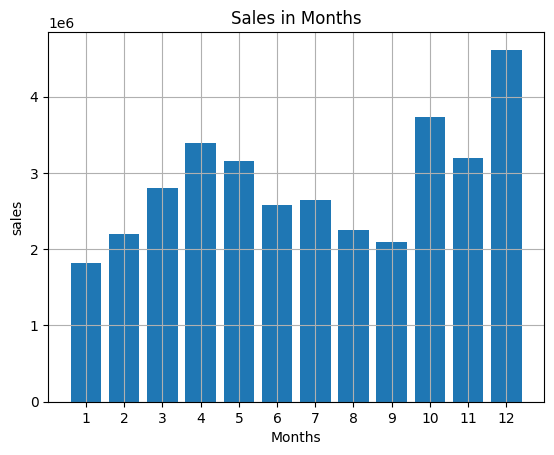

In [87]:

y=df.groupby('Month').sum()['sales']
x=range(1,13)
plt.bar(x,y)
plt.xticks(x)
plt.xlabel("Months")
plt.ylabel("sales")
plt.title('Sales in Months')
plt.grid()
plt.show()

Best City for Sales

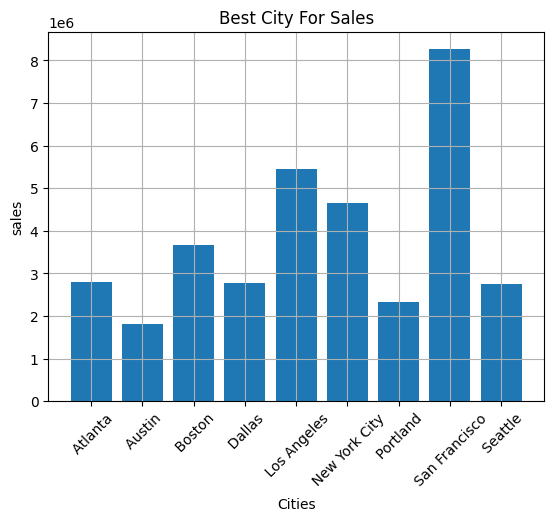

In [86]:
x=df.groupby('City').sum()['sales']
plt.bar(x.index,x.values)
plt.xticks(rotation=45)
plt.xlabel("Cities")
plt.ylabel("sales")
plt.grid()
plt.title("Best City For Sales")
plt.show()

Best time for Advertisement

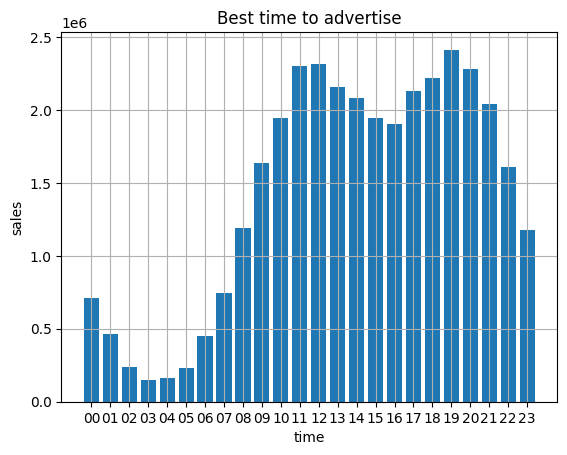

In [108]:
df.head()
x=df.groupby('Time').sum()['sales']
plt.bar(x.index,x.values)
plt.grid()
plt.xlabel("time")
plt.ylabel("sales")
plt.title("Best time to advertise")
plt.show()

Which product is sold the most

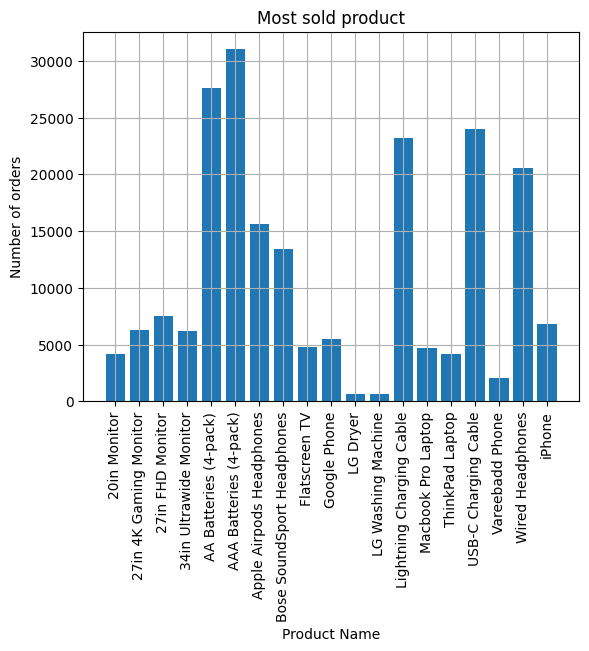

In [117]:
x=df.groupby("Product").sum()['Quantity Ordered']
plt.bar(x.index,x.values)
plt.xticks(rotation=90)
plt.xlabel('Product Name')
plt.ylabel('Number of orders')
plt.title("Most sold product")
plt.grid()
plt.show()
